# 02. Random Forest

This notebook trains a `Random Forest` baseline on the wallet-level table.

Included by default:

- stratified train/val/test split
- validation-based threshold tuning
- rich test metrics
- ROC curve, PR curve, confusion matrix, score histogram, threshold sweeps, calibration curve

Default restriction:

- `ADD_GRAPH_STATS = False`
- only wallet feature columns are used


In [9]:
from pathlib import Path
import sys

import pandas as pd

sys.path.append(str(Path.cwd()))

from tabular_model_utils import (
    build_tabular_dataset,
    classification_report_df,
    fit_and_evaluate_model,
    plot_evaluation_dashboard,
    plot_feature_importance,
    plot_mlp_learning_curve,
    set_seed,
)


In [10]:
MODEL_NAME = "random_forest"
FEATURE_GROUP = "eth_twitter_combined_features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
THRESHOLD_OBJECTIVE = "f1"

set_seed(RANDOM_STATE)


In [11]:
dataset = build_tabular_dataset(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
)

display(dataset["split_df"])
print("Number of input features:", len(dataset["feature_cols"]))
print("Scale positive weight:", round(dataset["scale_pos_weight"], 4))


,split,rows,positives,positive_ratio
0,train,7000,788,0.112571
1,val,1500,169,0.112667
2,test,1500,169,0.112667


Number of input features: 24
Scale positive weight: 7.8832


In [12]:
result = fit_and_evaluate_model(
    model_name=MODEL_NAME,
    dataset=dataset,
    random_state=RANDOM_STATE,
    threshold_objective=THRESHOLD_OBJECTIVE,
)

metrics_df = pd.DataFrame([result["metrics"]]).T.rename(columns={0: "value"})
display(metrics_df)


,value
Threshold,0.475000
PR-AUC,0.502753
ROC-AUC,0.842600
F1,0.501425
Precision,0.483516
Recall,0.520710
Specificity,0.929376
NPV,0.938543
Balanced-Accuracy,0.725043
MCC,0.435848


In [13]:
report_df = classification_report_df(
    dataset["y_test"].to_numpy(),
    result["test_prob"],
    result["threshold"],
)
display(report_df)


,precision,recall,f1-score,support
0,0.938543,0.929376,0.933937,1331.000000
1,0.483516,0.520710,0.501425,169.000000
accuracy,0.883333,0.883333,0.883333,0.883333
macro avg,0.711030,0.725043,0.717681,1500.000000
weighted avg,0.887277,0.883333,0.885208,1500.000000


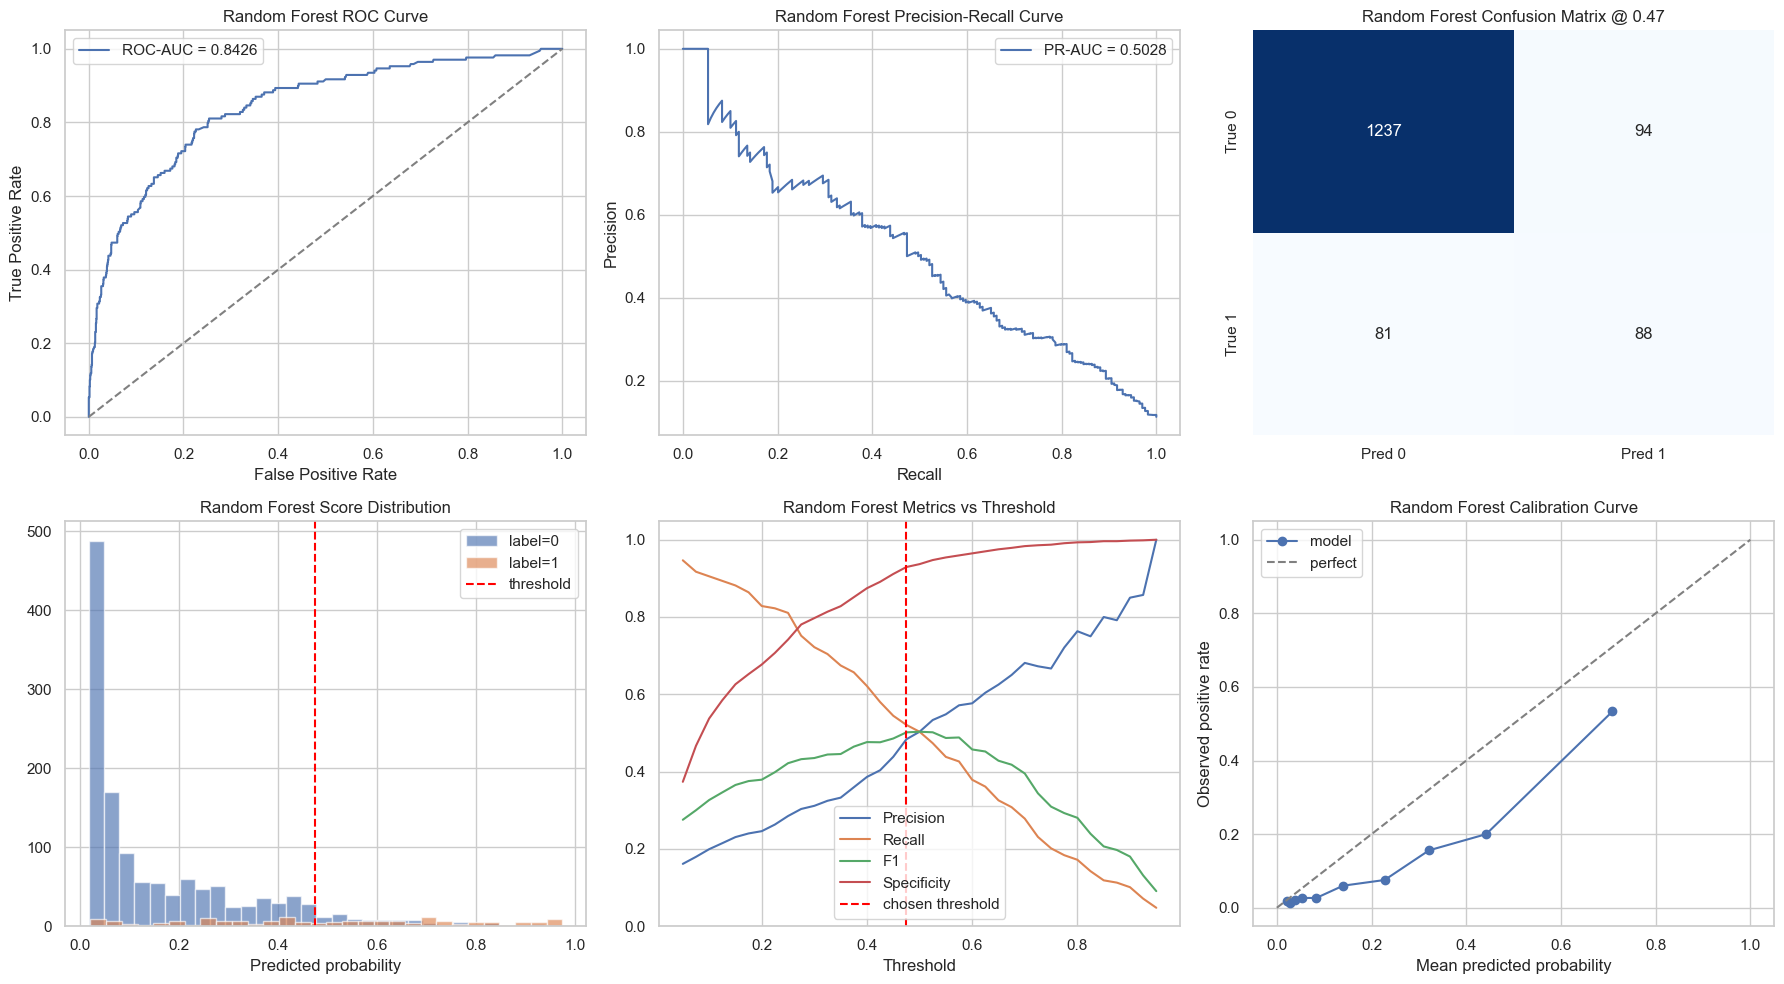

In [14]:
plot_evaluation_dashboard(
    y_true=dataset["y_test"].to_numpy(),
    y_prob=result["test_prob"],
    threshold=result["threshold"],
    title_prefix=MODEL_NAME.replace("_", " ").title(),
)


In [15]:
test_node_rows = dataset["nodes_df"].loc[dataset["test_idx"]].copy()
test_node_rows["predicted_probability"] = result["test_prob"]
test_node_rows["predicted_label"] = (result["test_prob"] >= result["threshold"]).astype(int)
suspicious_wallets = test_node_rows.sort_values("predicted_probability", ascending=False).head(25)
display(
    suspicious_wallets[
        [
            "node_id",
            "label",
            "predicted_probability",
            "predicted_label",
            "full_total_degree",
            "sub_total_degree",
        ]
    ]
)


,node_id,label,predicted_probability,predicted_label,full_total_degree,sub_total_degree
2478,308537,1,0.975077,1,1,1
2209,276703,1,0.972350,1,1,0
1539,204115,1,0.968165,1,1,1
1664,217839,1,0.964934,1,11,8
2046,258361,1,0.957752,1,2,0
9592,1225981,1,0.957635,1,1,1
9245,1190806,1,0.957477,1,1,1
9235,1190449,1,0.957477,1,3,2
9508,1215546,1,0.943533,1,1,1
5,205,0,0.938510,1,67,24


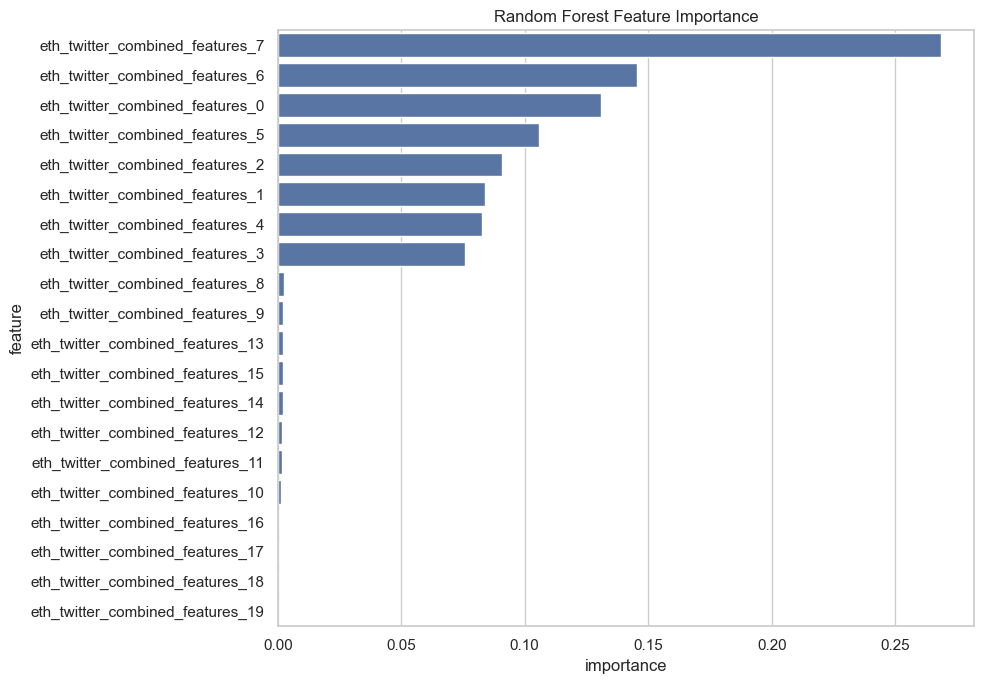

,feature,importance,signed_value
7,eth_twitter_combined_features_7,0.268466,0.268466
6,eth_twitter_combined_features_6,0.145439,0.145439
0,eth_twitter_combined_features_0,0.130863,0.130863
5,eth_twitter_combined_features_5,0.105824,0.105824
2,eth_twitter_combined_features_2,0.090922,0.090922
1,eth_twitter_combined_features_1,0.084050,0.084050
4,eth_twitter_combined_features_4,0.082888,0.082888
3,eth_twitter_combined_features_3,0.075922,0.075922
8,eth_twitter_combined_features_8,0.002400,0.002400
9,eth_twitter_combined_features_9,0.002171,0.002171


: 

In [ ]:
plot_feature_importance(
    model=result["model"],
    feature_cols=dataset["feature_cols"],
    title=f"{MODEL_NAME.replace('_', ' ').title()} Feature Importance",
    top_n=20,
)


## Notes

Use `PR-AUC`, `Recall`, `Precision`, `F1`, `Balanced-Accuracy`, and `MCC` together when comparing this model with the other baselines.
